# Removing Warm ACIS Data


In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
ASCDS_WORK_PATH=./
mkdir -p ./param

CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 13480
download_chandra_obsid 13480 evt2,mtl
mv 13480/*/*fits.gz .


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  evt2     fits        6 Mb  ####################          < 1 s  62442.1 kb/s
  mtl      fits        2 Mb  ####################          < 1 s  48661.4 kb/s

      Total download size for ObsId 13480 = 8 Mb
      Total download time for ObsId 13480 = < 1 s



In [3]:
cat << EOM > plot_fptemp.py
mtl=read_file("acisf13480_000N002_mtl1.fits.gz[cols time,fp_temp,Dist_SatEarth]")
times = mtl.get_column("time").values
time_offset = (times - times[0]) / 1000.0  # sec -> ksec
fp_temp = mtl.get_column("fp_temp").values
add_curve( time_offset, fp_temp)
set_curve("symbol.style=circle symbol.size=1")
set_curve("line.style=none")
set_plot_ylabel("FP\_TEMP [K]")
set_plot_xlabel("Time offset since {0} [ksec]".format(times[0]))
set_plot_title("OBS\_ID : 13480")
add_hline( 154.5, "line.style=dot")

# Overplot altitude
add_axis(Y_AXIS, 1, 0, 1 )
dist = mtl.get_column("dist_satearth").values / 1000 # meters -> km
add_curve( time_offset, dist )
set_curve("symbol.style=none")
set_curve("line.color=brown")
set_yaxis("ticklabel.angle=90 ticklabel.color=brown")
set_plot_ylabel("Distance [km]")
set_yaxis("offset.perpendicular=20 label.color=brown")
print_window("fptemp.png","export.clobber=True")
quit()
EOM

chips -b plot_fptemp.py


-----------------------------------------
Welcome to ChIPS: CXC's Plotting Package
-----------------------------------------
CIAO 4.9 ChIPS version 1 Friday, December 2, 2016



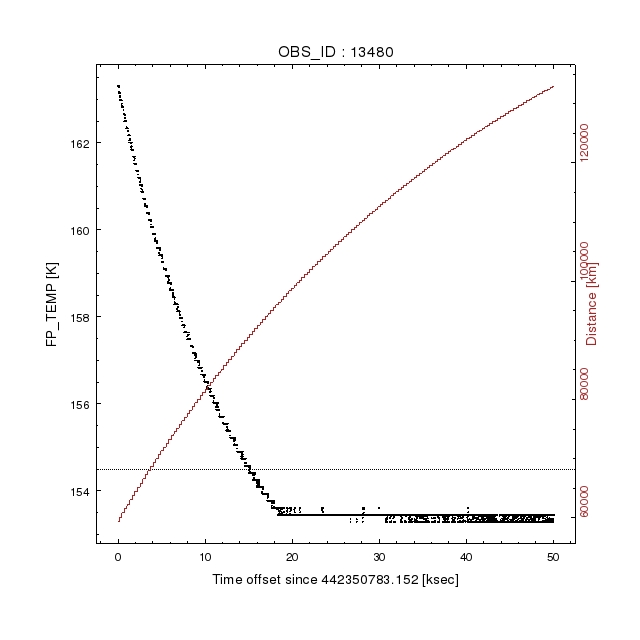

In [4]:
display < fptemp.png

## Choose GTIs


In [5]:
pset dmgti infile=acisf13480_000N002_mtl1.fits.gz
pset dmgti outfile=fp_temp.gti
pset dmgti userlimit="fp_temp<154.5"
pset dmgti mode=h clob+
dmgti

In [6]:
dmlist fp_temp.gti blocks,subspace

 
--------------------------------------------------------------------------------
Dataset: fp_temp.gti
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: FILTER                         Table         1 cols x 0        rows
Block    3: GTI                            Table         2 cols x 4        rows
 
--------------------------------------------------------------------------------
Data subspace for block FILTER: Components: 1 Descriptors: 1 
--------------------------------------------------------------------------------
 
 --- Component 1 --- 
   1 TIME                 Real8               TABLE GTI
                                              
                                              442365829.0019089580:442365847.6019091010
          

## Apply

In [7]:
dmcopy "acisf13480N002_evt2.fits.gz[@fp_temp.gti]" good_events.fits clob+

## Check

In [8]:
dmkeypar acisf13480N002_evt2.fits.gz ONTIME echo+

50052.600384951


In [9]:
dmkeypar good_events.fits ONTIME echo+

34896.700268388


# Cleanup


In [ ]:
/bin/rm -rf 13480
/bin/rm -f *.fits.gz
